<a href="https://colab.research.google.com/github/mneve920811/GitHubActionsDemo/blob/main/Solucion_Reto_SC_63_MARIANA_NEVE_RAMIREZ_WIELLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

In [2]:
# 2. CARGAR DATOS

from google.colab import files
uploaded = files.upload()

Saving bank_marketing.csv.csv to bank_marketing.csv (1).csv


In [3]:
# 3. DEFINIR DF COMO DATA

data = pd.read_csv("bank_marketing.csv.csv")

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes


In [4]:
# 4. INFORMACION DE LA BASE DE DATOS
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


In [5]:
# PASO 6 Y 7. DEFINIR TIPO DE VARIABLES Y CODIFICAR CATEGÓRICAS

# Variables numéricas
numeric_cols = [
    'age', 'balance', 'day', 'duration',
    'campaign', 'pdays', 'previous'
]

# Variables categóricas nominales
nominal_cols = [
    'job', 'marital', 'contact', 'month', 'poutcome'
]

# =========================
# CODIFICACIÓN
# =========================

# 1. Variables ordinales → Label Encoding (manual)
education_order = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}
data['education'] = data['education'].map(education_order)

# 2. Variables binarias → Label Encoding (manual)
binary_cols = ['default', 'housing', 'loan', 'y']

for col in binary_cols:
    data[col] = data[col].map({'no': 0, 'yes': 1})

# 3. Variables nominales → OneHot Encoding
data = pd.get_dummies(
    data=data,
    columns=nominal_cols,
    drop_first=True
)

# Verificar resultado
data.head()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,31,3,0,2666,0,0,10,318,2,97,...,False,False,False,False,True,False,False,False,True,False
1,29,0,0,1584,0,0,6,245,1,-1,...,False,False,False,False,False,False,True,False,False,True
2,41,2,0,2152,1,0,17,369,1,-1,...,False,False,False,False,True,False,False,False,False,True
3,50,2,0,84,1,0,17,18,8,-1,...,True,False,False,False,False,False,False,False,False,True
4,40,2,0,0,0,0,28,496,2,182,...,True,False,False,False,False,False,False,False,True,False


In [6]:
# PASO 8: DEFINICIÓN DE VARIABLES DE ENTRADA Y SALIDA

# Variable de salida
Y = data['y']

# Variables de entrada
X = data.drop('y', axis=1)

print("Dimensiones X:", X.shape)
print("Dimensiones Y:", Y.shape)

Dimensiones X: (9000, 40)
Dimensiones Y: (9000,)


In [7]:
# PASO 9: PARTICIÓN DE DATOS - 60%, 20% Y 20%

from sklearn.model_selection import train_test_split

# Primera partición: 60% entrenamiento, 40% temporal
X_train, X_val_test, Y_train, Y_val_test = train_test_split(
    X, Y,
    train_size=0.60,
    random_state=42,
    stratify=Y
)

# Segunda partición: 20% validación, 20% prueba
X_val, X_test, Y_val, Y_test = train_test_split(
    X_val_test, Y_val_test,
    train_size=0.50,
    random_state=42,
    stratify=Y_val_test
)

# Verificación de tamaños
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (5400, 40)
Validation: (1800, 40)
Test: (1800, 40)


Accuracy TRAIN: 0.8283333333333334
Accuracy VALIDATION: 0.82

Reporte de clasificación (Validación):
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1042
           1       0.81      0.75      0.78       758

    accuracy                           0.82      1800
   macro avg       0.82      0.81      0.81      1800
weighted avg       0.82      0.82      0.82      1800



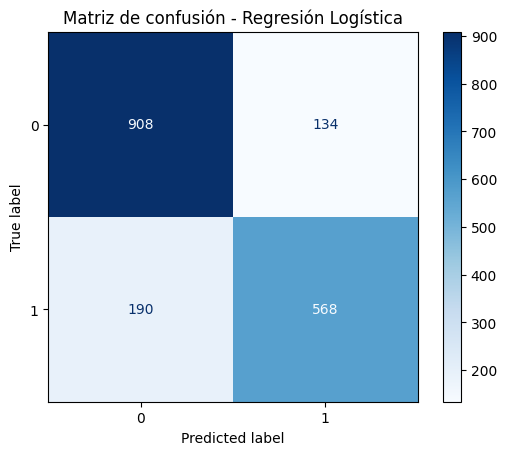

In [8]:
# PASO 10: REGRESIÓN LOGÍSTICA

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline con escalamiento
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=5000,
        solver='saga',   # mejor para datasets grandes / muchas dummies
        random_state=42
    ))
])

# Entrenamiento
pipe_log.fit(X_train, Y_train)

# Predicciones
y_train_pred_log = pipe_log.predict(X_train)
y_val_pred_log = pipe_log.predict(X_val)

# Accuracy
acc_train_log = accuracy_score(Y_train, y_train_pred_log)
acc_val_log = accuracy_score(Y_val, y_val_pred_log)

print("Accuracy TRAIN:", acc_train_log)
print("Accuracy VALIDATION:", acc_val_log)

# Reporte
print("\nReporte de clasificación (Validación):")
print(classification_report(Y_val, y_val_pred_log))

# Matriz de confusión
cm_log = confusion_matrix(Y_val, y_val_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

(2, 4) -> train_acc: 0.835, val_acc: 0.828, train_loss: 0.165, val_loss: 0.172
(4, 8) -> train_acc: 0.849, val_acc: 0.837, train_loss: 0.151, val_loss: 0.163
(6, 12) -> train_acc: 0.859, val_acc: 0.841, train_loss: 0.141, val_loss: 0.159
(8, 16) -> train_acc: 0.867, val_acc: 0.844, train_loss: 0.133, val_loss: 0.156
(10, 20) -> train_acc: 0.870, val_acc: 0.843, train_loss: 0.130, val_loss: 0.157
(12, 24) -> train_acc: 0.871, val_acc: 0.840, train_loss: 0.129, val_loss: 0.160
(14, 28) -> train_acc: 0.872, val_acc: 0.846, train_loss: 0.128, val_loss: 0.154
(16, 32) -> train_acc: 0.879, val_acc: 0.849, train_loss: 0.121, val_loss: 0.151
(18, 36) -> train_acc: 0.879, val_acc: 0.847, train_loss: 0.121, val_loss: 0.153
(20, 40) -> train_acc: 0.873, val_acc: 0.844, train_loss: 0.127, val_loss: 0.156
(22, 44) -> train_acc: 0.883, val_acc: 0.844, train_loss: 0.117, val_loss: 0.156
(24, 48) -> train_acc: 0.882, val_acc: 0.844, train_loss: 0.118, val_loss: 0.156


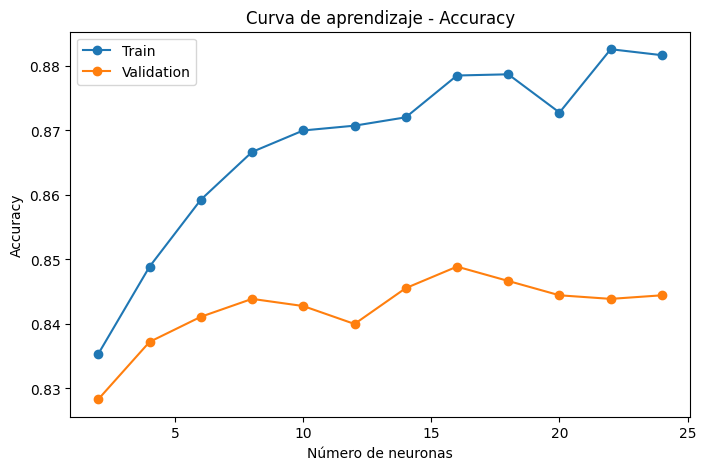

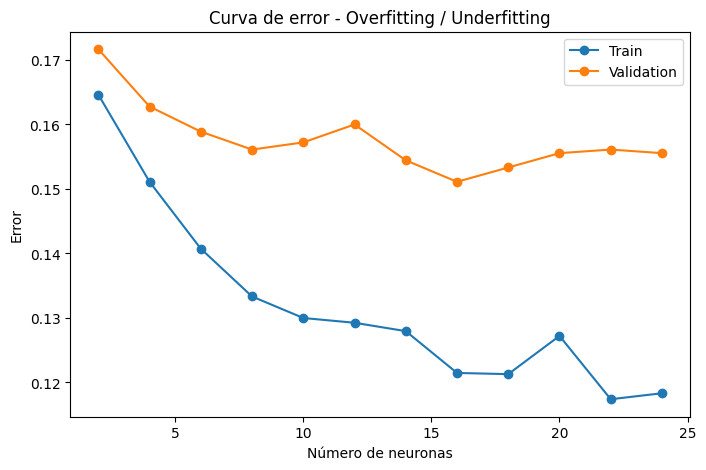


Mejor arquitectura encontrada: (16, 32)
Mejor accuracy en validación: 0.8488888888888889

Diagnóstico:
El modelo muestra un balance razonable entre entrenamiento y validación.


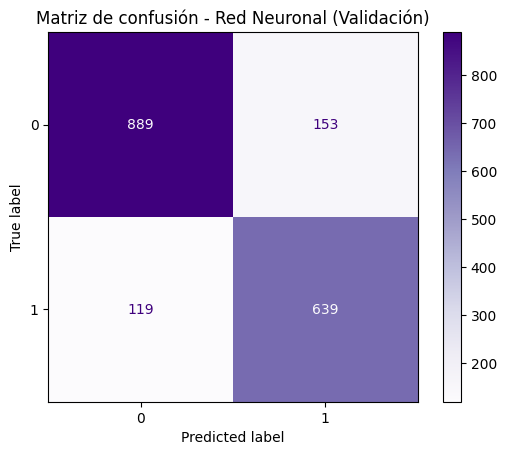


Reporte de clasificación en validación:
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1042
           1       0.81      0.84      0.82       758

    accuracy                           0.85      1800
   macro avg       0.84      0.85      0.85      1800
weighted avg       0.85      0.85      0.85      1800



In [9]:
# PASO 11: RED NEURONAL

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

neuronas = [i for i in range(2, 25, 2)]

train_scores, val_scores = [], []
train_errors, val_errors = [], []

best_val_acc = -1
best_model = None
best_neurons = None

for i in neuronas:

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(i, 2*i),
            max_iter=5000,
            learning_rate_init=0.001,
            alpha=2.1,
            random_state=42
        ))
    ])

    # Entrenamiento
    model.fit(X_train, np.ravel(Y_train))

    # TRAIN
    train_pred = model.predict(X_train)
    train_loss = np.mean(np.ravel(Y_train) != train_pred)
    train_acc = 1 - train_loss

    train_errors.append(train_loss)
    train_scores.append(train_acc)

    # VALIDACIÓN
    val_pred = model.predict(X_val)
    val_loss = np.mean(np.ravel(Y_val) != val_pred)
    val_acc = 1 - val_loss

    val_errors.append(val_loss)
    val_scores.append(val_acc)

    print("(%d, %d) -> train_acc: %.3f, val_acc: %.3f, train_loss: %.3f, val_loss: %.3f"
          % (i, 2*i, train_acc, val_acc, train_loss, val_loss))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_neurons = (i, 2*i)

# GRÁFICA ACCURACY
plt.figure(figsize=(8,5))
plt.plot(neuronas, train_scores, '-o', label='Train')
plt.plot(neuronas, val_scores, '-o', label='Validation')
plt.legend()
plt.title('Curva de aprendizaje - Accuracy')
plt.xlabel('Número de neuronas')
plt.ylabel('Accuracy')
plt.show()

# GRÁFICA ERROR
plt.figure(figsize=(8,5))
plt.plot(neuronas, train_errors, '-o', label='Train')
plt.plot(neuronas, val_errors, '-o', label='Validation')
plt.legend()
plt.title('Curva de error - Overfitting / Underfitting')
plt.xlabel('Número de neuronas')
plt.ylabel('Error')
plt.show()

print("\nMejor arquitectura encontrada:", best_neurons)
print("Mejor accuracy en validación:", best_val_acc)

# Diagnóstico automático
best_train_acc = max(train_scores)

print("\nDiagnóstico:")
if best_train_acc > best_val_acc + 0.05:
    print("Posible overfitting: el modelo aprende mejor en entrenamiento que en validación.")
elif best_val_acc < 0.70 and best_train_acc < 0.70:
    print("Posible underfitting: el modelo tiene bajo desempeño tanto en entrenamiento como en validación.")
else:
    print("El modelo muestra un balance razonable entre entrenamiento y validación.")

# MATRIZ DE CONFUSIÓN
best_val_pred = best_model.predict(X_val)

cm_val = confusion_matrix(Y_val, best_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot(cmap="Purples")
plt.title("Matriz de confusión - Red Neuronal (Validación)")
plt.show()

print("\nReporte de clasificación en validación:")
print(classification_report(Y_val, best_val_pred))

Regresión Logística - Train: 0.8283333333333334
Regresión Logística - Validation: 0.82

Red Neuronal - Train: 0.8785185185185185
Red Neuronal - Validation: 0.8488888888888889

Mejor modelo seleccionado: Red Neuronal

Diagnóstico del modelo seleccionado:
No se observa evidencia fuerte de sobreajuste o subajuste.

Accuracy final en prueba: 0.8444444444444444

Reporte de clasificación en prueba:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1043
           1       0.81      0.83      0.82       757

    accuracy                           0.84      1800
   macro avg       0.84      0.84      0.84      1800
weighted avg       0.85      0.84      0.84      1800



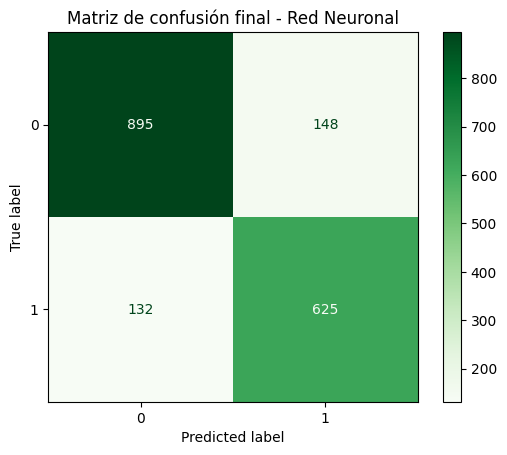

In [10]:

# PASO 12: SELECCIÓN DEL MEJOR MODELO Y EVALUACIÓN FINAL

# Validación Regresión Logística
y_train_pred_log = pipe_log.predict(X_train)
y_val_pred_log = pipe_log.predict(X_val)

acc_train_log = accuracy_score(Y_train, y_train_pred_log)
acc_val_log = accuracy_score(Y_val, y_val_pred_log)

# Validación Red Neuronal
y_train_pred_mlp = best_model.predict(X_train)
y_val_pred_mlp = best_model.predict(X_val)

acc_train_mlp = accuracy_score(Y_train, y_train_pred_mlp)
acc_val_mlp = accuracy_score(Y_val, y_val_pred_mlp)

print("Regresión Logística - Train:", acc_train_log)
print("Regresión Logística - Validation:", acc_val_log)

print("\nRed Neuronal - Train:", acc_train_mlp)
print("Red Neuronal - Validation:", acc_val_mlp)

# Selección del mejor modelo usando VALIDACIÓN
if acc_val_mlp > acc_val_log:
    final_model = best_model
    final_model_name = "Red Neuronal"
    final_train_acc = acc_train_mlp
    final_val_acc = acc_val_mlp
else:
    final_model = pipe_log
    final_model_name = "Regresión Logística"
    final_train_acc = acc_train_log
    final_val_acc = acc_val_log

print("\nMejor modelo seleccionado:", final_model_name)

# Diagnóstico de sobreajuste / subajuste
print("\nDiagnóstico del modelo seleccionado:")

if final_train_acc > final_val_acc + 0.05:
    print("Posible overfitting: el modelo tiene mejor desempeño en entrenamiento que en validación.")
elif final_train_acc < 0.70 and final_val_acc < 0.70:
    print("Posible underfitting: el modelo tiene bajo desempeño en ambos conjuntos.")
else:
    print("No se observa evidencia fuerte de sobreajuste o subajuste.")

# Evaluación final en TEST
y_test_pred = final_model.predict(X_test)
acc_test = accuracy_score(Y_test, y_test_pred)

print("\nAccuracy final en prueba:", acc_test)

print("\nReporte de clasificación en prueba:")
print(classification_report(Y_test, y_test_pred))

# Matriz de confusión final
cm_test = confusion_matrix(Y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(cmap="Greens")
plt.title(f"Matriz de confusión final - {final_model_name}")
plt.show()

In [11]:
# Número de iteraciones usadas
iters_log = pipe_log.named_steps['model'].n_iter_

print("Iteraciones usadas (Logística):", iters_log)

# Verificación de convergencia
if np.all(iters_log < 5000):
    print("La regresión logística CONVERGIÓ")
else:
    print("La regresión logística NO convergió completamente")

Iteraciones usadas (Logística): [26]
La regresión logística CONVERGIÓ
